In [1]:
from bs4 import BeautifulSoup
import requests 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

Names = []
Rating = []
Reviews = []
Cities = []
Occasions = []
Posted_On = []

In [2]:
url = "https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page="
#url = "https://www.floweraura.com/reviews/p/10172/divine-butterscotch-cake?page="

for i in range(1,51):
    cnp = url+str(i)
    url_new = cnp
    r = requests.get(url_new)
    
    soup = BeautifulSoup(r.text, "html.parser")
    
    main = soup.find("div", {"class":"review-left-container"})
    
    sub = main.find_all("div", {"class":"new-review-card-container"})
    
    for i in sub:
        name = i.find("span", {"class":"review-author-name"})
        Names.append(name.text.title())
    
        city = i.find_all("span", {"class":"review-meta-details"})
        Cities.append(city[0].text.title())
        try:
            Occasions.append(city[1].text.title())
        except:
            Occasions.append(np.nan)
            
        date = i.find_all("span")
        try:
            Posted_On.append(date[4].text)
        except:
            Posted_On.append(np.nan)
    
        rating = i.find("span", {"class":"star-count-container"})
        Rating.append(rating.text)
    
        review = i.find_all("div")
        Reviews.append(review[-1].text)

    
    

In [3]:
df = pd.DataFrame({'Names':Names, "Citites":Cities, "Posted_On":Posted_On, "Occasion":Occasions, "Ratings":Rating, "Reviews":Reviews})
df.to_csv("Flower_aura_product_reviews.csv")

In [166]:
def extract(value):
    try:
        x = value.index(':')
        return value[x+2:]
    except:
        return np.nan

df["Posted_On"] = df["Posted_On"].apply(extract)
df["Occasion"] = df["Occasion"].apply(extract)
df

,Names,Citites,Posted_On,Occasion,Ratings,Reviews
0,Inaya,Udaipur,31st Aug 2025,NaN,5,Very beautifull on tome delivered.
1,Nallapandiyan D,Coimbatore,11th Jul 2025,Birthday,4,Thanks for the timely delivery.
2,Ushashree Gangaputra,Hyderabad,11th Jun 2025,Love & Romance,5,"Beautiful red roses , reached before time Than..."
3,Tabassum Farooqui,Aligarh,25th Mar 2025,Anniversary,5,Flowers are fresh and beautiful. Thank you Flo...
4,Ajay Kumar,Delhi,11th Feb 2025,Rose Day,5,Thank you For Participation in my Loving Moment.
...,...,...,...,...,...,...
495,Prernasaini,Gurgaon,8th Sep 2023,NaN,5,Thank you so much
496,Jhanvi Jaiswal,Mumbai,7th Sep 2023,NaN,5,Thankyou somuch for helping and making my surp...
497,Shashikala,Varanasi,5th Sep 2023,Birthday,5,Loved it
498,Anu Sharma,Chandigarh,5th Sep 2023,Birthday,5,Stunning flower


In [167]:
rep = ["th", "rd", "st", "nd"]

for i in rep:
    df["Posted_On"] = df["Posted_On"].str.replace(i, "")


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Names      500 non-null    object
 1   Citites    500 non-null    object
 2   Posted_On  500 non-null    object
 3   Occasion   387 non-null    object
 4   Ratings    500 non-null    object
 5   Reviews    500 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [169]:
df["Posted_On"] = pd.to_datetime(df["Posted_On"])


In [170]:
df["Ratings"] = df["Ratings"].astype("int")

In [171]:
df["Polarity"] = [TextBlob(i).sentiment.polarity for i in df["Reviews"]]

In [172]:
df["Subjectivity"] = [TextBlob(i).subjectivity for i in df["Reviews"]]

In [173]:
df

,Names,Citites,Posted_On,Occasion,Ratings,Reviews,Polarity,Subjectivity
0,Inaya,Udaipur,2025-08-31,NaN,5,Very beautifull on tome delivered.,0.200000,0.300000
1,Nallapandiyan D,Coimbatore,2025-07-11,Birthday,4,Thanks for the timely delivery.,0.200000,0.200000
2,Ushashree Gangaputra,Hyderabad,2025-06-11,Love & Romance,5,"Beautiful red roses , reached before time Than...",0.425000,0.500000
3,Tabassum Farooqui,Aligarh,2025-03-25,Anniversary,5,Flowers are fresh and beautiful. Thank you Flo...,0.716667,0.600000
4,Ajay Kumar,Delhi,2025-02-11,Rose Day,5,Thank you For Participation in my Loving Moment.,0.600000,0.950000
...,...,...,...,...,...,...,...,...
495,Prernasaini,Gurgaon,2023-09-08,NaN,5,Thank you so much,0.200000,0.200000
496,Jhanvi Jaiswal,Mumbai,2023-09-07,NaN,5,Thankyou somuch for helping and making my surp...,0.408333,0.758333
497,Shashikala,Varanasi,2023-09-05,Birthday,5,Loved it,0.700000,0.800000
498,Anu Sharma,Chandigarh,2023-09-05,Birthday,5,Stunning flower,0.500000,1.000000


In [174]:
p = df["Polarity"].mean()

if p <= -0.3:
    print("negative")
elif p < 0.3:
    print("neutral")
else:
    print('positive')
    


positive


In [188]:
def score(value):
    if value <= 0:
        return "negative"
    else:
        return 'positive'

df["Score"] = df["Polarity"].apply(score)

In [189]:
df

,Names,Citites,Posted_On,Occasion,Ratings,Reviews,Polarity,Subjectivity,Score
0,Inaya,Udaipur,2025-08-31,NaN,5,Very beautifull on tome delivered.,0.200000,0.300000,positive
1,Nallapandiyan D,Coimbatore,2025-07-11,Birthday,4,Thanks for the timely delivery.,0.200000,0.200000,positive
2,Ushashree Gangaputra,Hyderabad,2025-06-11,Love & Romance,5,"Beautiful red roses , reached before time Than...",0.425000,0.500000,positive
3,Tabassum Farooqui,Aligarh,2025-03-25,Anniversary,5,Flowers are fresh and beautiful. Thank you Flo...,0.716667,0.600000,positive
4,Ajay Kumar,Delhi,2025-02-11,Rose Day,5,Thank you For Participation in my Loving Moment.,0.600000,0.950000,positive
...,...,...,...,...,...,...,...,...,...
495,Prernasaini,Gurgaon,2023-09-08,NaN,5,Thank you so much,0.200000,0.200000,positive
496,Jhanvi Jaiswal,Mumbai,2023-09-07,NaN,5,Thankyou somuch for helping and making my surp...,0.408333,0.758333,positive
497,Shashikala,Varanasi,2023-09-05,Birthday,5,Loved it,0.700000,0.800000,positive
498,Anu Sharma,Chandigarh,2023-09-05,Birthday,5,Stunning flower,0.500000,1.000000,positive


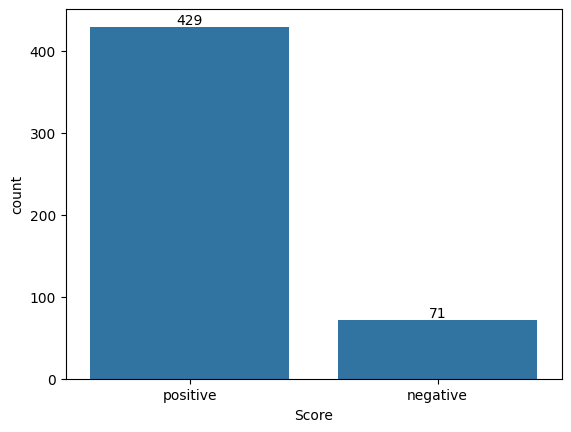

In [190]:
ax = sns.countplot(x = df['Score'], data = df)

ax.bar_label(container=ax.containers[0])
plt.show()

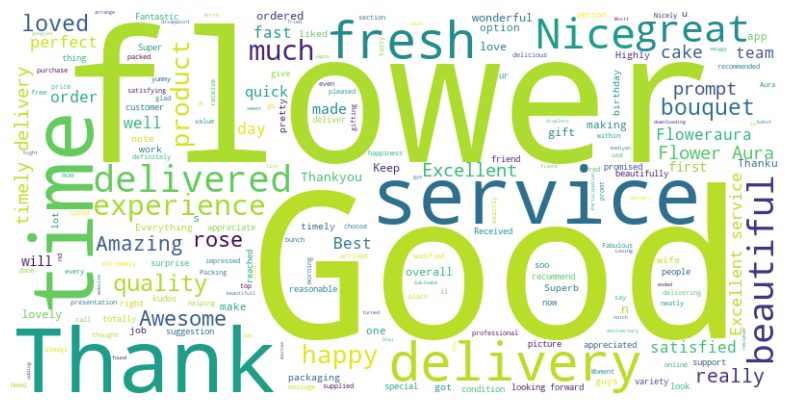

In [194]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
# Join all text entries from the column into a single string
df_pos = df.loc[(df["Score"] == "positive")]
df_neg = df.loc[(df["Score"] == "negative")]

all_text = " ".join(text for text in df_pos['Reviews'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

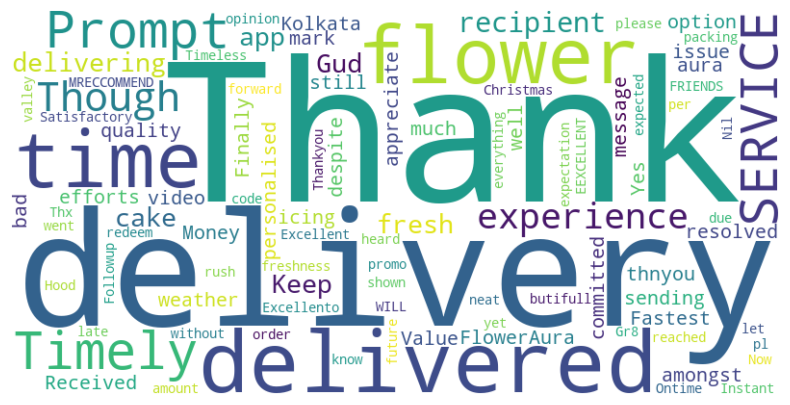

In [192]:
all_text = " ".join(text for text in df_neg['Reviews'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()